<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Iris-Visualization/Iris_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
# Load the Iris dataset from seaborn
iris = sns.load_dataset("iris")

# Preview first 5 rows
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Shape, column names
print(f"Shape: {iris.shape}")
print(f"Columns: {iris.columns.tolist()}")


Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [4]:
# Data types and null check
iris.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Missing values
print("Missing values:")
print(iris.isnull().sum())


Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
# Descriptive statistics
iris.describe().round(2)


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [7]:
# Species count
print(iris["species"].value_counts())


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


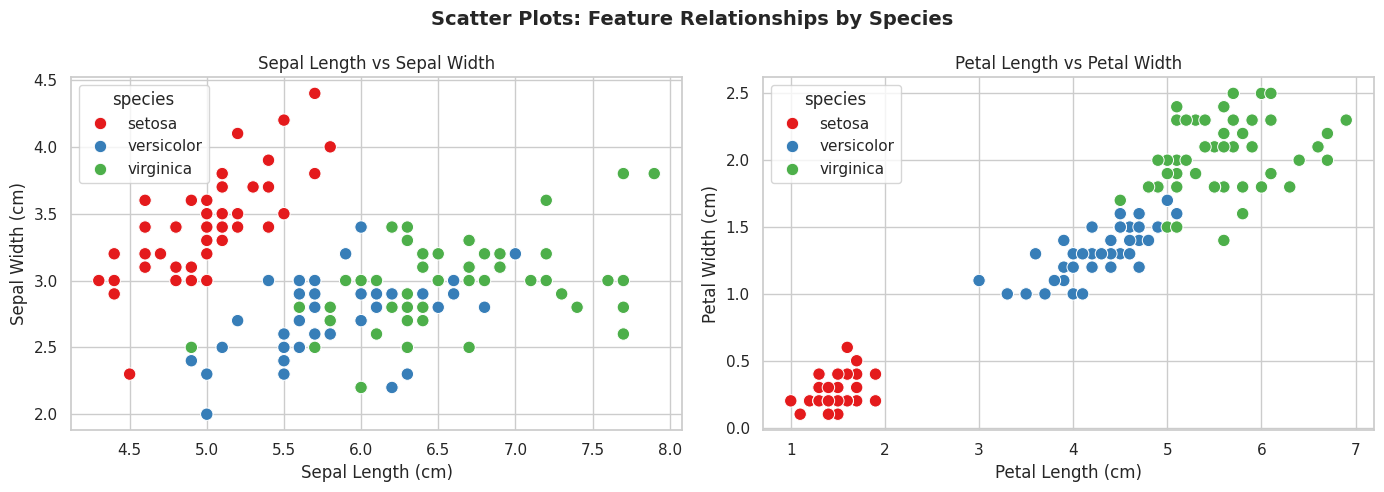

In [8]:
# Scatter plots: feature relationships by species
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=iris, x="sepal_length", y="sepal_width",
                hue="species", palette="Set1", s=80, ax=axes[0])
axes[0].set_title("Sepal Length vs Sepal Width")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")

sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                hue="species", palette="Set1", s=80, ax=axes[1])
axes[1].set_title("Petal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.suptitle("Scatter Plots: Feature Relationships by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()


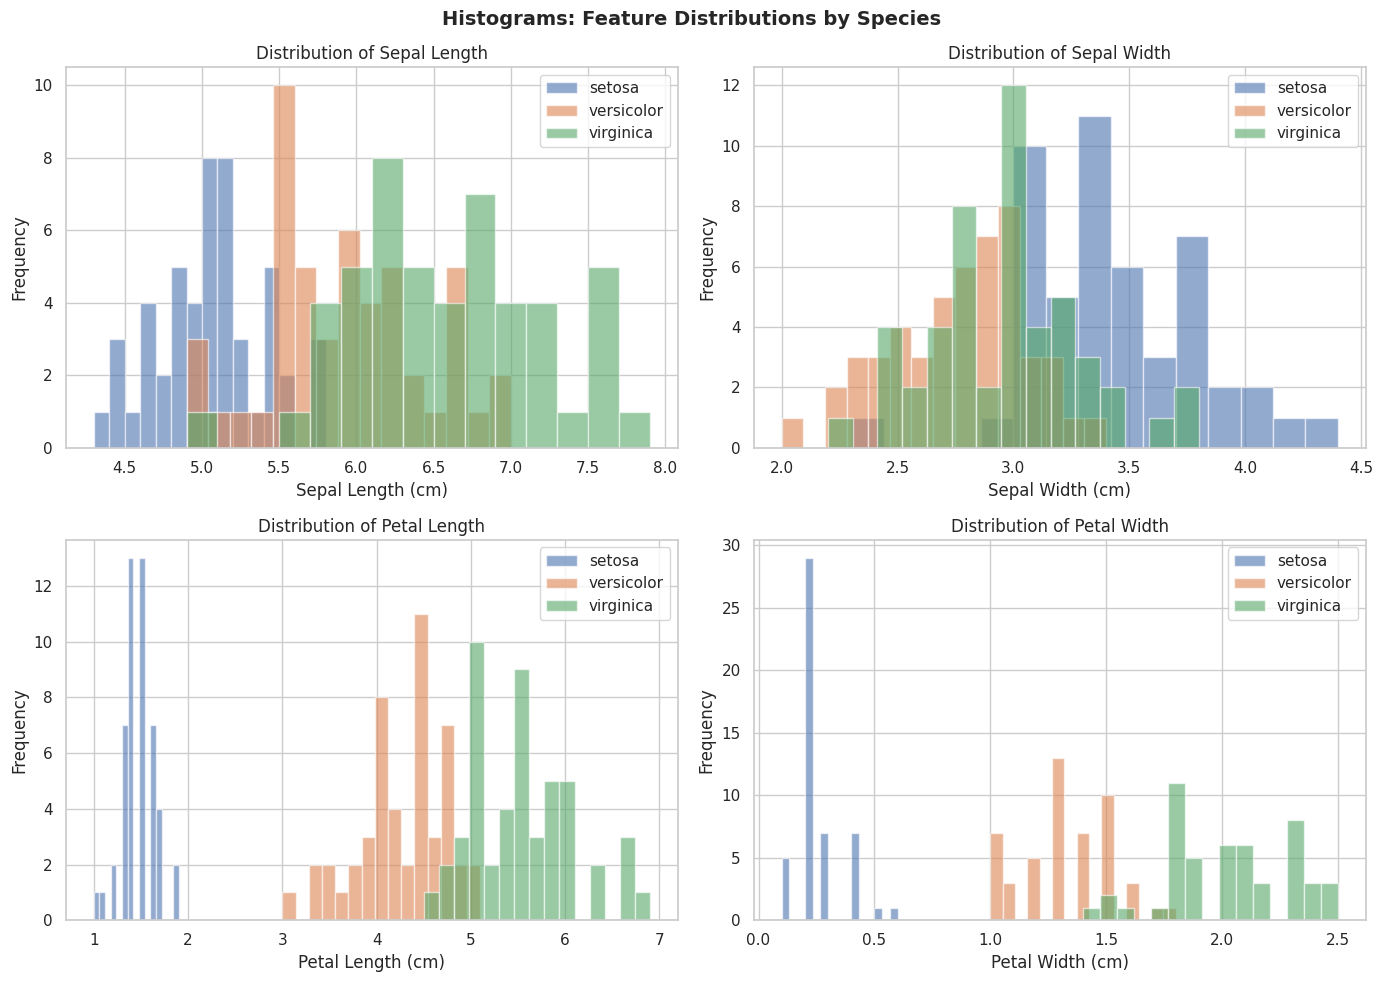

In [9]:
# Histograms: value distributions per feature per species
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species in iris["species"].unique():
        subset = iris[iris["species"] == species]
        axes[i].hist(subset[feature], bins=15, alpha=0.6, label=species, edgecolor="white")
    axes[i].set_title(f"Distribution of {feature.replace('_', ' ').title()}")
    axes[i].set_xlabel(f"{feature.replace('_', ' ').title()} (cm)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Histograms: Feature Distributions by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("histograms.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_1059/1051914000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=feature,
/tmp/ipykernel_1059/1051914000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=feature,
/tmp/ipykernel_1059/1051914000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x="species", y=feature,
/tmp/ipykernel_1059/1051914000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fa

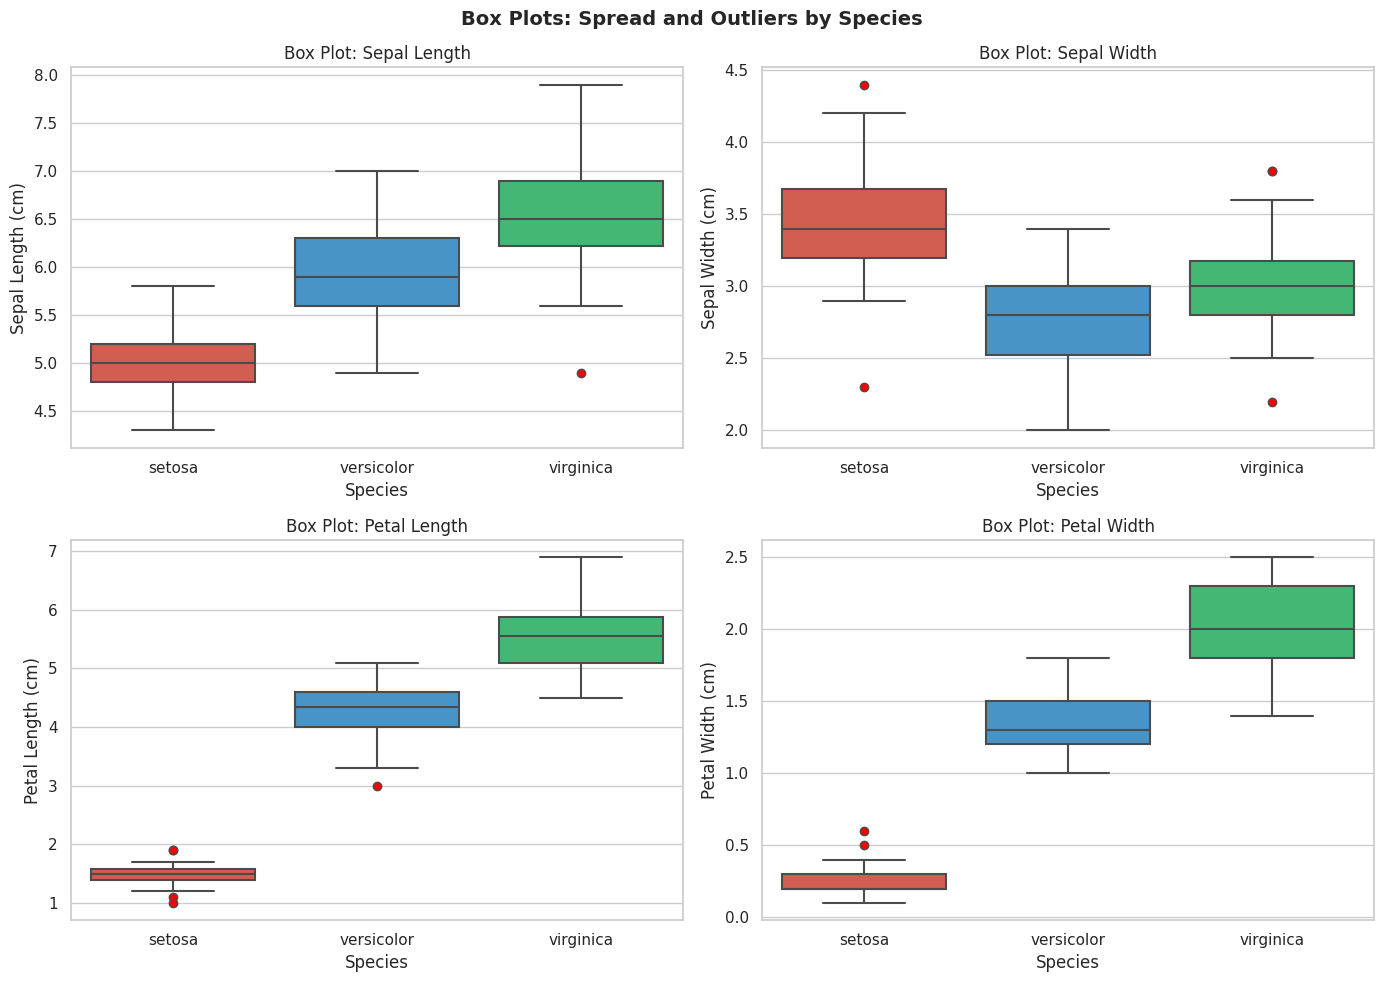

In [10]:
# Box plots: spread and outliers per species
palette = {"setosa": "#E74C3C", "versicolor": "#3498DB", "virginica": "#2ECC71"}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=iris, x="species", y=feature,
                palette=palette, ax=axes[i], linewidth=1.5,
                flierprops=dict(marker="o", markerfacecolor="red", markersize=6))
    axes[i].set_title(f"Box Plot: {feature.replace('_', ' ').title()}")
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(f"{feature.replace('_', ' ').title()} (cm)")

plt.suptitle("Box Plots: Spread and Outliers by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


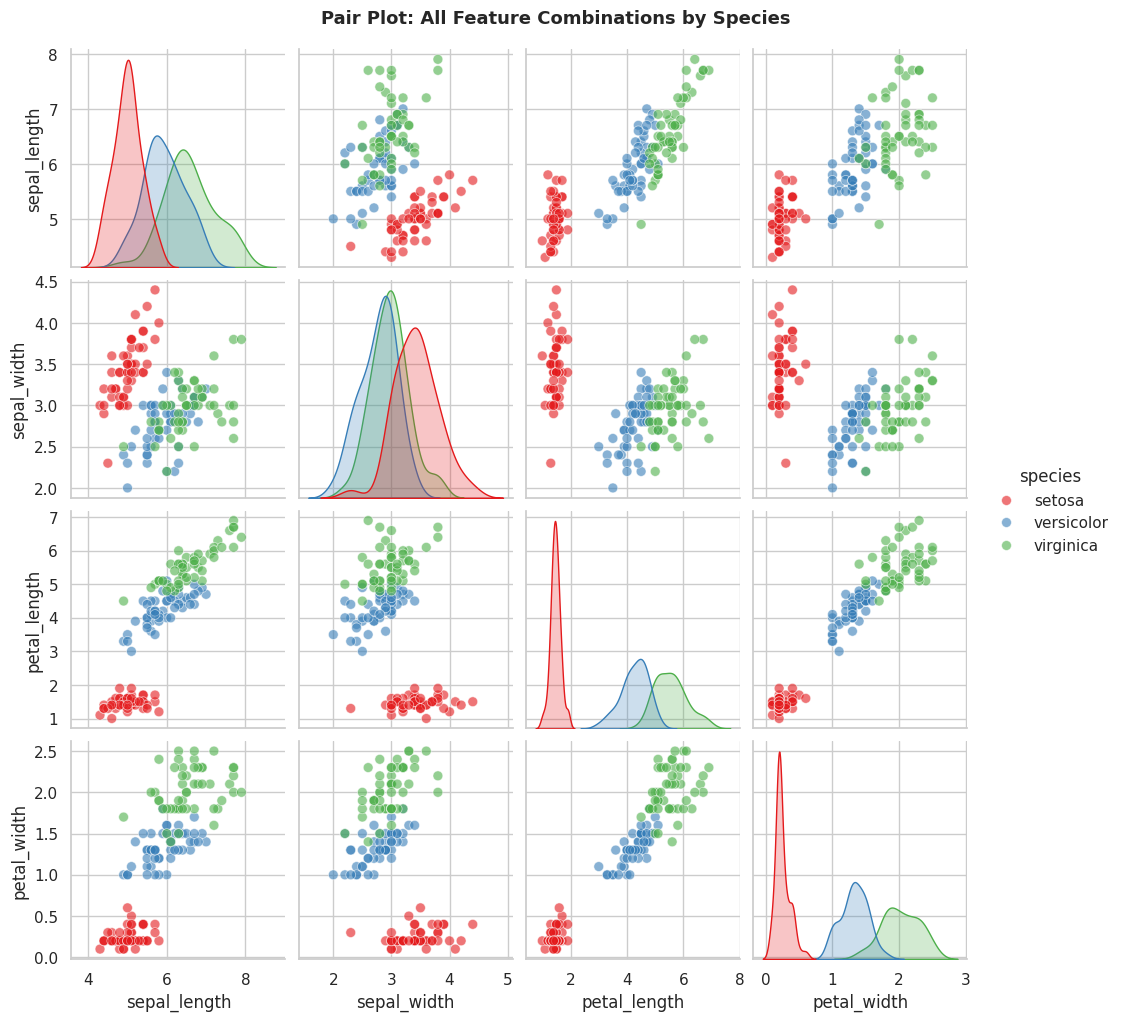

In [11]:
# Pair plot: all feature combinations
pair_plot = sns.pairplot(iris, hue="species", palette="Set1",
                         diag_kind="kde", plot_kws={"alpha": 0.6, "s": 50})
pair_plot.fig.suptitle("Pair Plot: All Feature Combinations by Species", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


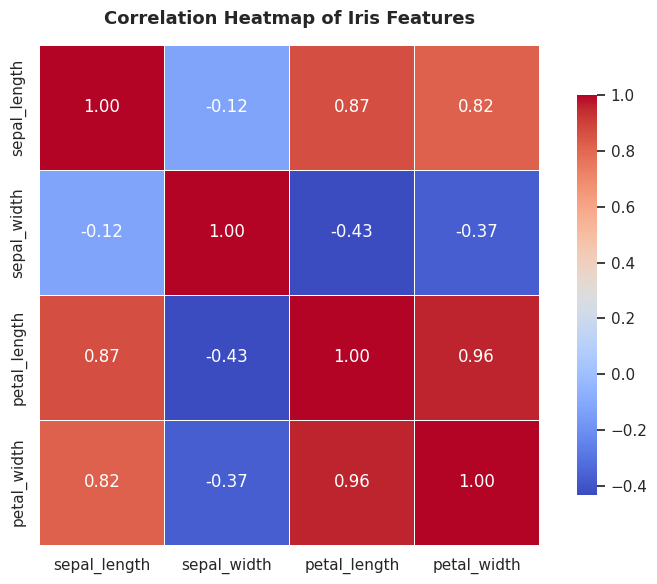

In [12]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = iris.drop(columns="species").corr().round(2)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 12})
plt.title("Correlation Heatmap of Iris Features", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
